# Notebook 05 – Deck Builder

## Objective

In this notebook, we construct legal Pokémon Trading Card Game decks.

The Deck Builder uses the Card Knowledge Base created in Notebook 04 to assemble 60-card decks while enforcing official Pokémon TCG deck-building rules.

By the end of this notebook, we will:

- Load the Card Knowledge Base
- Build searchable card objects
- Classify cards by category
- Create legal Pokémon decks
- Validate deck legality
- Prepare decks for AI battle simulation

This notebook provides the foundation for battle engine development.

In [1]:
from pathlib import Path
import pandas as pd
import pickle

PROJECT_ROOT = Path.cwd()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print(PROJECT_ROOT)

D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge


In [2]:
cards = pd.read_csv(
    PROCESSED_DIR / "pokemon_cards_processed.csv"
)

print(cards.shape)
cards.head()

(2022, 43)


,Card ID,Card Name,Expansion,Collection No.,Stage (Pokémon)/Type (Energy and Trainer),Rule,Category,Previous stage,HP,Type,...,mobility_score,evolution_score,has_rule_box,overall_battle_score,is_pokemon,is_trainer,is_energy,card_category,has_attack,has_ability
0,1,Basic {G} Energy,SVE,1,Basic Energy,NaN,NaN,NaN,NaN,{G},...,1.0,0.0,0,1.0,0,0,1,Energy,0,0
1,2,Basic {R} Energy,SVE,2,Basic Energy,NaN,NaN,NaN,NaN,{R},...,1.0,0.0,0,1.0,0,0,1,Energy,0,0
2,3,Basic {W} Energy,SVE,3,Basic Energy,NaN,NaN,NaN,NaN,{W},...,1.0,0.0,0,1.0,0,0,1,Energy,0,0
3,4,Basic {L} Energy,SVE,4,Basic Energy,NaN,NaN,NaN,NaN,{L},...,1.0,0.0,0,1.0,0,0,1,Energy,0,0
4,5,Basic {P} Energy,SVE,5,Basic Energy,NaN,NaN,NaN,NaN,{P},...,1.0,0.0,0,1.0,0,0,1,Energy,0,0


The processed card dataset has been successfully loaded.

This dataset contains all engineered battle features and serves as the foundation for deck construction.

In [3]:
card_base = (
    cards
    .drop_duplicates(subset="Card ID")
    .copy()
)

print("Unique cards:", len(card_base))

Unique cards: 1267


In [4]:
attack_lists = (
    cards
    .groupby("Card ID")
    .apply(
        lambda df: df[
            [
                "Move Name",
                "Cost",
                "Damage",
                "Effect Explanation",
                "energy_cost",
                "damage_numeric"
            ]
        ].to_dict("records")
    )
    .reset_index(name="attacks")
)

card_base = card_base.merge(
    attack_lists,
    on="Card ID",
    how="left"
)

In [5]:
card_objects = {}

for _, row in card_base.iterrows():

    card_objects[row["Card ID"]] = {

        "card_id": row["Card ID"],
        "name": row["Card Name"],
        "category": row["card_category"],
        "stage": row["Stage (Pokémon)/Type (Energy and Trainer)"],
        "hp": row["HP"],
        "type": row["primary_type"],
        "weakness": row["weakness_type"],
        "resistance": row["resistance_type"],
        "retreat": row["retreat_numeric"],
        "overall_score": row["overall_battle_score"],
        "attacks": row["attacks"],
        "rule": row["Rule"],
        "effect": row["Effect Explanation"]

    }

print("Total card objects:", len(card_objects))

Total card objects: 1267


In [6]:
knowledge_base_file = PROCESSED_DIR / "card_knowledge_base.pkl"

with open(knowledge_base_file, "wb") as f:
    pickle.dump(card_objects, f)

print("Knowledge Base saved!")
print(knowledge_base_file)

Knowledge Base saved!
D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\data\processed\card_knowledge_base.pkl


The Card Knowledge Base has been serialized into a pickle file.

Future notebooks can load the knowledge base instantly without rebuilding it from the processed dataset.

In [7]:
with open(knowledge_base_file, "rb") as f:
    loaded_cards = pickle.load(f)

print("Loaded:", len(loaded_cards), "cards")


Loaded: 1267 cards


In [8]:
first_key = next(iter(loaded_cards))

loaded_cards[first_key]

{'card_id': 1,
 'name': 'Basic {G} Energy',
 'category': 'Energy',
 'stage': 'Basic Energy',
 'hp': nan,
 'type': 'Grass',
 'weakness': nan,
 'resistance': nan,
 'retreat': 0.0,
 'overall_score': 1.0,
 'attacks': [{'Move Name': nan,
   'Cost': nan,
   'Damage': nan,
   'Effect Explanation': nan,
   'energy_cost': 0,
   'damage_numeric': 0.0}],
 'rule': nan,
 'effect': nan}

In [9]:
with open(PROCESSED_DIR / "card_knowledge_base.pkl", "rb") as f:
    cards = pickle.load(f)

In [11]:
pokemon_cards = {
    card_id: card
    for card_id, card in cards.items()
    if card["category"] == "Pokémon"
}

trainer_cards = {
    card_id: card
    for card_id, card in cards.items()
    if card["category"] == "Trainer"
}

energy_cards = {
    card_id: card
    for card_id, card in cards.items()
    if card["category"] == "Energy"
}

print("Pokémon cards:", len(pokemon_cards))
print("Trainer cards:", len(trainer_cards))
print("Energy cards:", len(energy_cards))

Pokémon cards: 1056
Trainer cards: 191
Energy cards: 20


## Observation

The Card Knowledge Base has been separated into Pokémon, Trainer, and Energy card groups.

This structure will allow the Deck Builder to select balanced deck components.

# Step 11 – Define Deck Size Rules

A standard Pokémon TCG deck contains exactly 60 cards.

For this first prototype, we will build a simple deck structure using:

- 20 Pokémon
- 30 Trainer cards
- 10 Energy cards

Later, we can optimize these ratios using AI.

In [12]:
DECK_SIZE = 60

POKEMON_COUNT = 20
TRAINER_COUNT = 30
ENERGY_COUNT = 10

print("Deck size:", DECK_SIZE)
print("Pokémon:", POKEMON_COUNT)
print("Trainers:", TRAINER_COUNT)
print("Energy:", ENERGY_COUNT)
print("Total:", POKEMON_COUNT + TRAINER_COUNT + ENERGY_COUNT)

Deck size: 60
Pokémon: 20
Trainers: 30
Energy: 10
Total: 60


## Observation

The initial deck template contains 60 total cards.

This provides a simple baseline deck composition for the first Deck Builder prototype.

# Step 12 – Build First Random Deck

We now create a simple 60-card deck by randomly selecting cards from each category.

This first deck is not optimized yet. It is only a baseline prototype to confirm that the Deck Builder works.

In [13]:
import random

random.seed(42)

selected_pokemon = random.sample(list(pokemon_cards.values()), POKEMON_COUNT)
selected_trainers = random.sample(list(trainer_cards.values()), TRAINER_COUNT)
selected_energy = random.sample(list(energy_cards.values()), ENERGY_COUNT)

starter_deck = selected_pokemon + selected_trainers + selected_energy

print("Deck size:", len(starter_deck))

Deck size: 60


In [14]:
deck_summary = pd.DataFrame(starter_deck)

deck_summary[["name", "category", "type", "hp", "overall_score"]].head(20)

,name,category,type,hp,overall_score
0,Eevee ex,Pokémon,Colorless,200.0,101.500000
1,Sawsbuck,Pokémon,Grass,130.0,44.666667
2,Blitzle,Pokémon,Lightning,60.0,40.500000
3,Beheeyem,Pokémon,Psychic,90.0,46.500000
4,Squawkabilly,Pokémon,Colorless,70.0,55.500000
5,Dudunsparce ex,Pokémon,Colorless,270.0,69.750000
6,Pecharunt,Pokémon,Darkness,80.0,40.500000
7,Scatterbug,Pokémon,Grass,40.0,20.500000
8,Pancham,Pokémon,Fighting,70.0,43.666667
9,Metang,Pokémon,Metal,100.0,34.666667


## Observation

A baseline 60-card deck was successfully created using Pokémon, Trainer, and Energy cards.

This confirms that the Deck Builder can assemble cards from the Card Knowledge Base.

# Step 13 – Validate Deck Structure

The Deck Builder needs a validation function to check whether a deck follows the expected structure.

For this prototype, the validator checks:

- Total deck size
- Number of Pokémon cards
- Number of Trainer cards
- Number of Energy cards
- Whether the deck contains at least one Basic Pokémon

In [16]:
def validate_deck(deck):
    deck_size = len(deck)

    pokemon_count = sum(card["category"] == "Pokémon" for card in deck)
    trainer_count = sum(card["category"] == "Trainer" for card in deck)
    energy_count = sum(card["category"] == "Energy" for card in deck)

    basic_pokemon_count = sum(
        card["stage"] == "Basic Pokémon"
        for card in deck
    )

    validation_results = {
        "deck_size": deck_size,
        "pokemon_count": pokemon_count,
        "trainer_count": trainer_count,
        "energy_count": energy_count,
        "basic_pokemon_count": basic_pokemon_count,
        "is_60_cards": deck_size == 60,
        "has_basic_pokemon": basic_pokemon_count > 0,
        "matches_template": (
            pokemon_count == POKEMON_COUNT
            and trainer_count == TRAINER_COUNT
            and energy_count == ENERGY_COUNT
        )
    }

    validation_results["is_valid_prototype_deck"] = (
        validation_results["is_60_cards"]
        and validation_results["has_basic_pokemon"]
        and validation_results["matches_template"]
    )

    return validation_results

In [17]:
validate_deck(starter_deck)

{'deck_size': 60,
 'pokemon_count': 20,
 'trainer_count': 30,
 'energy_count': 10,
 'basic_pokemon_count': 12,
 'is_60_cards': True,
 'has_basic_pokemon': True,
 'matches_template': True,
 'is_valid_prototype_deck': True}

## Observation

The validation function checks whether the starter deck follows the prototype rules.

This creates the foundation for stricter deck legality checks in later versions.

# Step 14 – Analyze Deck Statistics

Now that we have a valid deck, we can analyze its characteristics.

These statistics will later help AI compare and optimize different deck builds.

In [18]:
import pandas as pd

deck_df = pd.DataFrame(starter_deck)

deck_stats = {
    "Average HP": deck_df["hp"].fillna(0).mean(),
    "Average Battle Score": deck_df["overall_score"].mean(),
    "Average Retreat Cost": deck_df["retreat"].fillna(0).mean(),
    "Unique Pokémon Types": deck_df["type"].dropna().nunique(),
    "Pokémon Cards": sum(deck_df["category"] == "Pokémon"),
    "Trainer Cards": sum(deck_df["category"] == "Trainer"),
    "Energy Cards": sum(deck_df["category"] == "Energy")
}

pd.DataFrame(
    deck_stats.items(),
    columns=["Statistic", "Value"]
)

,Statistic,Value
0,Average HP,38.000000
1,Average Battle Score,20.059722
2,Average Retreat Cost,0.466667
3,Unique Pokémon Types,10.000000
4,Pokémon Cards,20.000000
5,Trainer Cards,30.000000
6,Energy Cards,10.000000


## Observation

The generated statistics summarize the overall characteristics of the starter deck.

These metrics will later be used to compare deck quality and evaluate AI-generated decks.

# Step 15 – Pokémon Type Distribution

In [19]:
pokemon_df = deck_df[
    deck_df["category"] == "Pokémon"
]

pokemon_df["type"].value_counts()

type
Colorless    5
Grass        3
Lightning    3
Fighting     3
Psychic      2
Darkness     1
Metal        1
Fire         1
Water        1
Name: count, dtype: int64

<Axes: title={'center': 'Pokémon Types in Starter Deck'}, xlabel='type'>

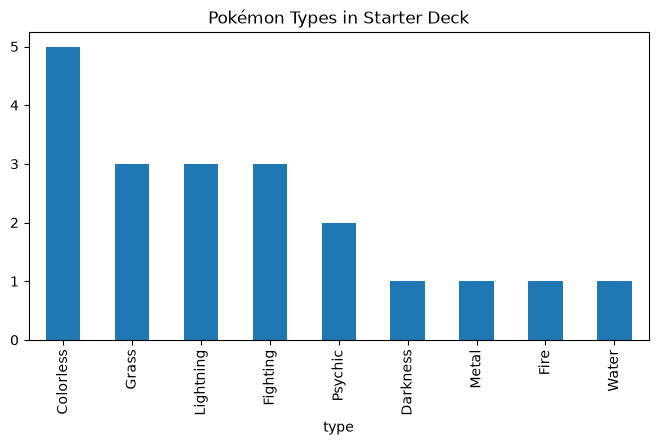

In [20]:
pokemon_df["type"].value_counts().plot(
    kind="bar",
    figsize=(8,4),
    title="Pokémon Types in Starter Deck"
)

# Step 16 – Check Duplicate Card Counts

A Pokémon TCG deck should not contain too many copies of the same card.

In this prototype, we check how many times each card name appears in the deck.

Later, we will enforce the official duplicate rule more strictly.

In [23]:
deck_df["name"].value_counts().head(20)

name
Eevee ex                  1
Sawsbuck                  1
Blitzle                   1
Beheeyem                  1
Squawkabilly              1
Dudunsparce ex            1
Pecharunt                 1
Scatterbug                1
Pancham                   1
Metang                    1
Excadrill                 1
Rotom                     1
Team Rocket's Rattata     1
Volcarona                 1
Hawlucha                  1
Iron Leaves ex            1
Team Rocket's Ampharos    1
Spectrier                 1
Kangaskhan                1
Glalie                    1
Name: count, dtype: int64

In [24]:
duplicate_counts = deck_df["name"].value_counts()

duplicate_counts[duplicate_counts > 4]

Series([], Name: count, dtype: int64)

## Observation

The duplicate count check identifies whether any card appears more than four times.

This prepares the Deck Builder for official Pokémon TCG legality validation.

# Step 17 – Strict Deck Legality Check

The prototype deck validator checks deck size and category counts.

Now we add a stricter legality function that checks whether any non-basic-energy card appears more than four times.

Basic Energy cards are allowed to appear more than four times.

In [25]:
def check_duplicate_rule(deck):
    deck_df = pd.DataFrame(deck)

    duplicate_counts = deck_df["name"].value_counts()

    violations = {}

    for card_name, count in duplicate_counts.items():
        card_rows = deck_df[deck_df["name"] == card_name]

        is_basic_energy = (
            card_rows["category"].iloc[0] == "Energy"
            and "Basic" in card_name
            and "Energy" in card_name
        )

        if count > 4 and not is_basic_energy:
            violations[card_name] = count

    return violations

In [26]:
duplicate_violations = check_duplicate_rule(starter_deck)

duplicate_violations

{}

## Observation

The duplicate-rule checker identifies non-basic-energy cards that appear more than four times.

This moves the Deck Builder closer to official Pokémon TCG deck legality validation.

## Step 18 – Final Deck Validation Function

In [27]:
def validate_full_deck(deck):
    base_validation = validate_deck(deck)
    duplicate_violations = check_duplicate_rule(deck)

    base_validation["duplicate_violations"] = duplicate_violations
    base_validation["passes_duplicate_rule"] = len(duplicate_violations) == 0

    base_validation["is_fully_valid"] = (
        base_validation["is_valid_prototype_deck"]
        and base_validation["passes_duplicate_rule"]
    )

    return base_validation

In [28]:
validate_full_deck(starter_deck)

{'deck_size': 60,
 'pokemon_count': 20,
 'trainer_count': 30,
 'energy_count': 10,
 'basic_pokemon_count': 12,
 'is_60_cards': True,
 'has_basic_pokemon': True,
 'matches_template': True,
 'is_valid_prototype_deck': True,
 'duplicate_violations': {},
 'passes_duplicate_rule': True,
 'is_fully_valid': True}

## Observation

The final validation function combines deck-size checks, category checks, Basic Pokémon checks, and duplicate-card checks.

This creates a reusable validation tool for future AI-generated decks.

# Step 19 – Build a Type-Based Deck

Instead of selecting cards completely at random, we now build a deck around a chosen Pokémon type.

This is the first step toward strategy-based deck construction.

In [29]:
def build_type_deck(target_type, pokemon_count=20, trainer_count=30, energy_count=10):
    type_pokemon = [
        card for card in pokemon_cards.values()
        if card["type"] == target_type
    ]

    if len(type_pokemon) < pokemon_count:
        raise ValueError(f"Not enough {target_type} Pokémon available.")

    selected_pokemon = random.sample(type_pokemon, pokemon_count)
    selected_trainers = random.sample(list(trainer_cards.values()), trainer_count)
    selected_energy = random.sample(list(energy_cards.values()), energy_count)

    deck = selected_pokemon + selected_trainers + selected_energy

    return deck

In [30]:
lightning_deck = build_type_deck("Lightning")

validate_full_deck(lightning_deck)

{'deck_size': 60,
 'pokemon_count': 20,
 'trainer_count': 30,
 'energy_count': 10,
 'basic_pokemon_count': 13,
 'is_60_cards': True,
 'has_basic_pokemon': True,
 'matches_template': True,
 'is_valid_prototype_deck': True,
 'duplicate_violations': {},
 'passes_duplicate_rule': True,
 'is_fully_valid': True}

In [31]:
pd.DataFrame(lightning_deck)[
    ["name", "category", "type", "hp", "overall_score"]
].head(20)

,name,category,type,hp,overall_score
0,Electrike,Pokémon,Lightning,70.0,65.500000
1,Electabuzz,Pokémon,Lightning,90.0,55.333333
2,Mega Manectric ex,Pokémon,Lightning,330.0,393.000000
3,Raikou,Pokémon,Lightning,120.0,75.500000
4,Zeraora,Pokémon,Lightning,100.0,70.500000
5,Eelektross,Pokémon,Lightning,160.0,102.250000
6,Tapu Koko,Pokémon,Lightning,120.0,60.500000
7,Electivire ex,Pokémon,Lightning,280.0,58.200000
8,Emolga,Pokémon,Lightning,70.0,71.000000
9,Luxray,Pokémon,Lightning,150.0,153.000000


## Observation

A type-focused deck was successfully generated.

This strategy allows the Deck Builder to create decks based on a selected Pokémon type rather than choosing Pokémon randomly.

# Step 20 – Save Generated Decks

The Deck Builder has now created valid prototype decks.

We save these decks so that future notebooks, especially the Battle Engine notebook, can load them directly without rebuilding them.

In [32]:
import pickle

starter_deck_file = PROCESSED_DIR / "starter_deck.pkl"
lightning_deck_file = PROCESSED_DIR / "lightning_deck.pkl"

with open(starter_deck_file, "wb") as f:
    pickle.dump(starter_deck, f)

with open(lightning_deck_file, "wb") as f:
    pickle.dump(lightning_deck, f)

print("Starter deck saved:", starter_deck_file)
print("Lightning deck saved:", lightning_deck_file)

Starter deck saved: D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\data\processed\starter_deck.pkl
Lightning deck saved: D:\02_AI_and_Data\Kaggle-AI-Agents\PTCG_AI_Battle_Challenge\data\processed\lightning_deck.pkl


# Step 21 – Verify Saved Decks

After saving generated decks, we reload them to confirm that they were stored correctly.

In [33]:
with open(starter_deck_file, "rb") as f:
    loaded_starter_deck = pickle.load(f)

with open(lightning_deck_file, "rb") as f:
    loaded_lightning_deck = pickle.load(f)

print("Loaded starter deck:", len(loaded_starter_deck), "cards")
print("Loaded lightning deck:", len(loaded_lightning_deck), "cards")

Loaded starter deck: 60 cards
Loaded lightning deck: 60 cards


In [34]:
print("Starter Deck Validation")
print(validate_full_deck(loaded_starter_deck))

print("\nLightning Deck Validation")
print(validate_full_deck(loaded_lightning_deck))

Starter Deck Validation
{'deck_size': 60, 'pokemon_count': 20, 'trainer_count': 30, 'energy_count': 10, 'basic_pokemon_count': 12, 'is_60_cards': True, 'has_basic_pokemon': True, 'matches_template': True, 'is_valid_prototype_deck': True, 'duplicate_violations': {}, 'passes_duplicate_rule': True, 'is_fully_valid': True}

Lightning Deck Validation
{'deck_size': 60, 'pokemon_count': 20, 'trainer_count': 30, 'energy_count': 10, 'basic_pokemon_count': 13, 'is_60_cards': True, 'has_basic_pokemon': True, 'matches_template': True, 'is_valid_prototype_deck': True, 'duplicate_violations': {}, 'passes_duplicate_rule': True, 'is_fully_valid': True}


## Observation

Both generated decks were saved and reloaded successfully.

The saved deck files can now be used by the future Battle Engine notebook.